Gamma Correction dark picture

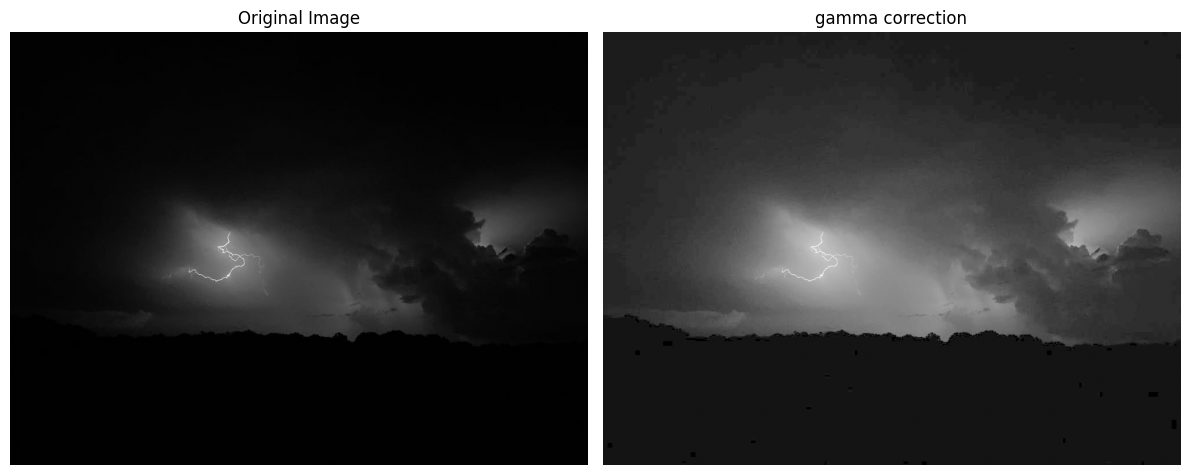

In [28]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def apply_gamma(image_path, gamma=2.2):
    img = Image.open(image_path).convert('L')
    image_data = np.array(img)

    normalized_img = image_data / 255.0
    corrected_img = np.power(normalized_img, 1.0 / gamma)
    final_img = np.uint8(corrected_img * 255)

    return Image.fromarray(final_img)


original_img = Image.open('overdarkimg.jpeg').convert('L')

equalized_img = apply_gamma('overdarkimg.jpeg')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(equalized_img, cmap='gray')
axes[1].set_title('gamma correction')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Histogram Equalized Low Contrast Picture

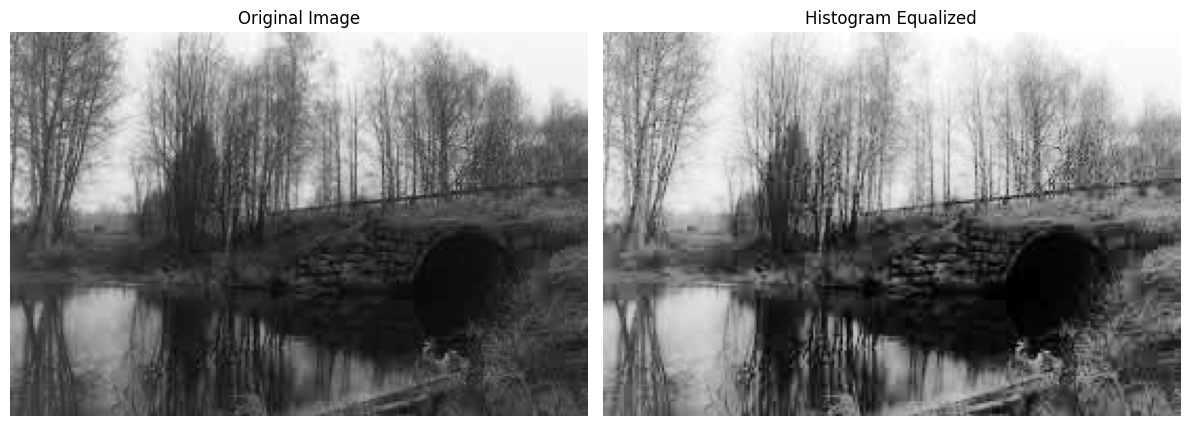

In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def histogram_equalization(image_path):
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    hist = np.zeros(256)
    for pixel in img_np.flatten():
        hist[pixel] += 1

    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    num_pixels = img_np.size
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (num_pixels - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    
    equalized_img = cdf[img_np]
    return Image.fromarray(equalized_img)
original_img = Image.open('img_sample.jpg').convert('L')

equalized_img = histogram_equalization('img_sample.jpg')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(equalized_img, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()

blurred image spatial filtering and sharpening

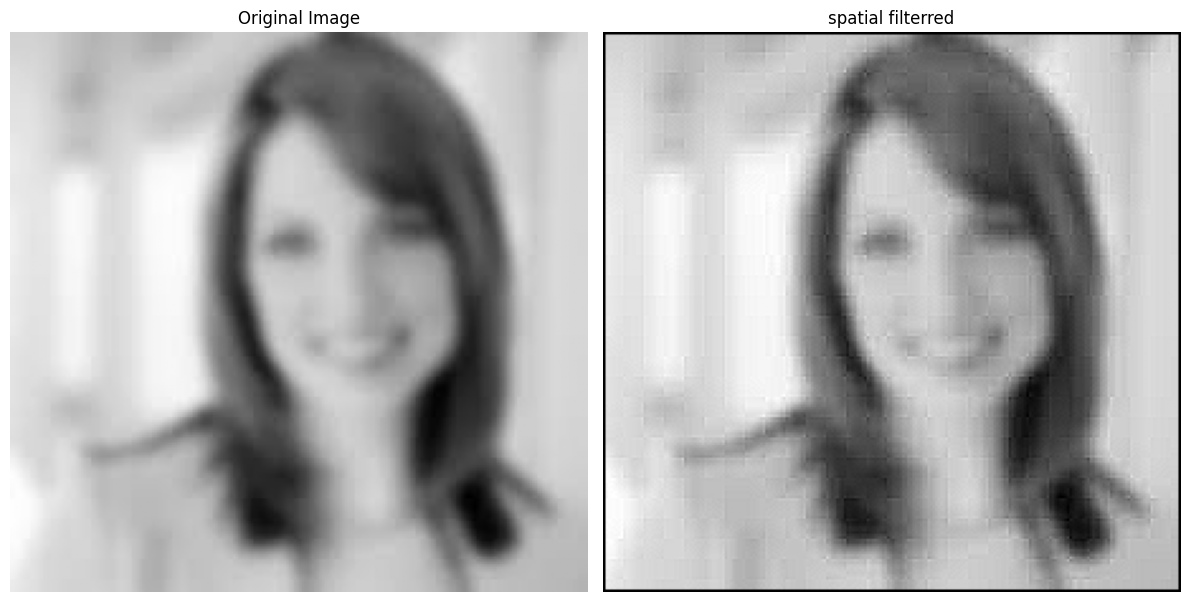

In [34]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def spatial_filtering(image_path):
    img = Image.open(image_path).convert('L')
    image_data = np.array(img, dtype=float) 
    height, width = image_data.shape
    output_image = np.zeros((height, width), dtype=float)
    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
    
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            neighbor_sum = 0
            for ki in range(-1, 2):
                for kj in range(-1, 2):
                    neighbor_sum += image_data[i+ki][j+kj] * kernel[ki+1][kj+1]
            output_image[i][j] = neighbor_sum

    output_image = np.clip(output_image, 0, 255)
    return Image.fromarray(np.uint8(output_image))

original_img = Image.open('blurry.jpg').convert('L')

unblurred_img = spatial_filtering('blurry.jpg')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(unblurred_img, cmap='gray')
axes[1].set_title('spatial filterred')
axes[1].axis('off')

plt.tight_layout()
plt.show()